In [14]:
import os
import sys
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt

In [2]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = C:\Users\hodor\Documents\lab-Shishkin\projects\Agency EBCI\Agency_BCI


In [3]:
from src.utils.parse_bci_iv_files import process_file
from src.utils.events import slice_epochs
from src.utils.save_helpers import make_unique_filename

from src.analysis.preprocessing import bandpass_filter
from src.analysis.CSP import calculate_CSP, calculate_robust_cov
from src.analysis.spectral_analysis import get_fft

from src.visualization.plot_csp_components import plot_10_csp_components

from scripts.calculate_fbcsp import calculate_csp_in_bands

In [4]:
data_folder = r"C:\Users\hodor\Documents\lab-MSU\диссер\Дупло белки\mu_clf\data\BCI Competition IV"
records = os.listdir(data_folder)
records = [record for record in os.listdir(data_folder) if record.find("calib") != -1]

eeg, idxs_1, idxs_2, xy, Fs = process_file(os.path.join(data_folder, records[0]))

In [123]:
choose = False       #<-------------------------- ввести вручную
band = [8, 12]      #<-------------------------- ввести вручную

In [124]:
sel_comp = [58, 57] #<-------------------------- ввести вручную

In [125]:
def epoch_cov(epoch):
    """
    epoch: [samples, channels]
    """
    X = epoch - np.mean(epoch, axis=0, keepdims=True)
    C = X.T @ X
    return C / np.trace(C)

def class_cov(epochs):
    """
    epochs: [n_epochs, samples, channels]
    """
    covs = [epoch_cov(ep) for ep in epochs]
    return np.mean(covs, axis=0)

In [126]:
import scipy.linalg as la

def compute_csp(epochs1, epochs2):
    """
    epochs1, epochs2 : [n_epochs, samples, channels]

    Returns
    -------
    W : spatial filters
    A : spatial patterns (для визуализации)
    eigvals : eigenvalues
    """

    def epoch_cov(epoch):
        X = epoch - np.mean(epoch, axis=0, keepdims=True)
        C = X.T @ X
        return C / np.trace(C)

    def class_cov(epochs, alpha=.1):
        covs = [epoch_cov(ep) for ep in epochs]
        C = np.mean(covs, axis=0)
        C = (1 - alpha) * C + alpha * np.trace(C)/C.shape[0] * np.eye(C.shape[0])
        return C

    C1 = class_cov(epochs1)
    C2 = class_cov(epochs2)

    C = C1 + C2

    # whitening
    eigvals, eigvecs = la.eigh(C)
    P = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T

    S1 = P.T @ C1 @ P

    eigvals, B = la.eigh(S1)

    W = P @ B

    # сортировка
    order = np.argsort(eigvals)
    W = W[:, order]
    eigvals = eigvals[order]

    # spatial patterns
    A = la.pinv(W).T

    return W, A, eigvals

In [127]:
def apply_csp(epochs, W, sel_components=[0, 1]):
    """
    epochs: [n_epochs, samples, channels]
    """
    # sel = np.r_[0:n_components//2, -n_components//2:0]

    epochs_csp = np.array([
        ep @ W[:, sel_components] for ep in epochs
    ])

    return epochs_csp

In [142]:
def csp_features(epochs_csp):
    """
    epochs_csp: [n_epochs, samples, components]
    """
    feats = []

    for ep in epochs_csp:
        var = np.var(ep, axis=0)
        var /= np.sum(var)
        feats.append(np.log(var))

    return np.array(feats)

In [143]:
# epochs
epochs_1 = slice_epochs(eeg, idxs_1)
epochs_2 = slice_epochs(eeg, idxs_2)

# CSP
W, A, eigvals = compute_csp(epochs_1, epochs_2)

# projections
sel_components = [0, 1, -1, -2]
epochs_1_csp = apply_csp(epochs_1, W, sel_components=sel_components)
epochs_2_csp = apply_csp(epochs_2, W, sel_components=sel_components)

# features
X1 = csp_features(epochs_1_csp)
X2 = csp_features(epochs_2_csp)

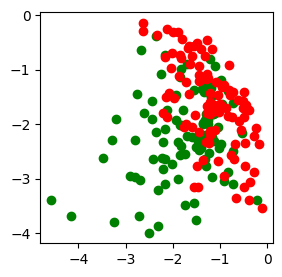

In [137]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.scatter(X1[:, 1], X1[:, 0], color='green')
ax.scatter(X2[:, 1], X2[:, 0], color='red')

In [138]:
def get_fft_feature(epoch, diff_ind_f=[10, 11, 12, 21, 22, 23]):
    fft_res, fft_t = get_fft(epoch, Fs=Fs, hop=int(0.1 * Fs), window=int(1 * Fs))
    feature = np.mean(fft_res[diff_ind_f, :, :], axis=0)        # усредняем по частотам 
    return np.mean(feature, axis=1)                             # усредняем по времени

feat_1 = np.array([get_fft_feature(epoch) for epoch in epochs_1_csp])
feat_2 = np.array([get_fft_feature(epoch) for epoch in epochs_2_csp])

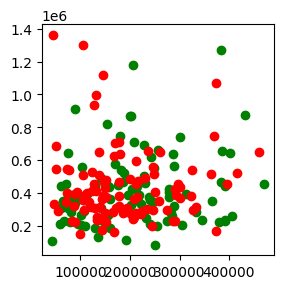

In [139]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.scatter(feat_1[:, 0], feat_1[:, 1], color='green')
ax.scatter(feat_2[:, 0], feat_2[:, 1], color='red')

In [144]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_validate

In [ ]:
X = np.concatenate([feat_1, feat_2], axis=0)
y = np.concatenate([np.ones(len(feat_1)), np.zeros(len(feat_2))])
lda = LDA()
scores = cross_validate(lda, X, y, cv=5, scoring=('accuracy', 'balanced_accuracy'), return_train_score=True)
print(scores["test_accuracy"])

[0.675 0.525 0.5   0.65  0.525]


In [151]:
X = np.concatenate([X1, X2], axis=0)
y = np.concatenate([np.ones(len(X1)), np.zeros(len(X2))])
lda = LDA()
scores = cross_validate(lda, X, y, cv=5, scoring=('accuracy', 'balanced_accuracy'), return_train_score=True)
print(scores["test_accuracy"])

[0.775 0.7   0.625 0.675 0.775]


In [10]:
eeg_f = bandpass_filter(eeg, fs=Fs, low=band[0], high=band[1])
epochs_1, epochs_2 = slice_epochs(eeg_f, idxs_1), slice_epochs(eeg_f, idxs_2)

edges_ms=250
n = edges_ms // (1000 // Fs)

cov1 = calculate_robust_cov(epochs_1[:, n:-n, :]).covariance_
cov2 = calculate_robust_cov(epochs_2[:, n:-n, :]).covariance_

In [11]:
projInverse, projForward, evals = calculate_CSP(cov1, cov2)

In [ ]:
eeg_csp = eeg @ projInverse[:, sel_comp]
epochs_1, epochs_2 = slice_epochs(eeg_csp, idxs_1), slice_epochs(eeg_csp, idxs_2)

In [52]:
def get_fft_feature(epoch, diff_ind_f=[10, 11, 12, 21, 22, 23]):
    fft_res, fft_t = get_fft(epoch, Fs=Fs, hop=int(0.1 * Fs), window=int(1 * Fs))
    feature = np.mean(fft_res[diff_ind_f, :, :], axis=0)        # усредняем по частотам 
    return np.mean(feature, axis=1)                             # усредняем по времени

feat_1 = np.array([get_fft_feature(epoch) for epoch in epochs_1])
feat_2 = np.array([get_fft_feature(epoch) for epoch in epochs_2])

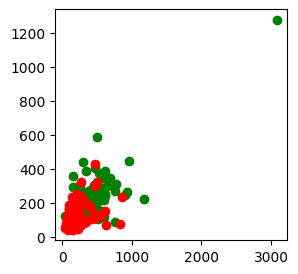

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.scatter(feat_1[:, 0], feat_1[:, 1], color='green')
ax.scatter(feat_2[:, 0], feat_2[:, 1], color='red')

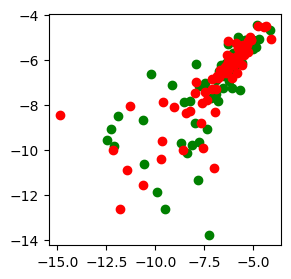

In [58]:
def get_csp_features(epoch):
    var = np.var(epoch, axis=1)
    var = var / np.sum(var)
    return np.log(var)

feat_1 = np.array([get_csp_features(epoch) for epoch in epochs_1])
feat_2 = np.array([get_csp_features(epoch) for epoch in epochs_2])

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.scatter(feat_1[:, 0], feat_1[:, 1], color='green')
ax.scatter(feat_2[:, 0], feat_2[:, 1], color='red')

In [ ]:
eeg.shape, epochs_1[0].shape

((190594, 59), (400, 2))